<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

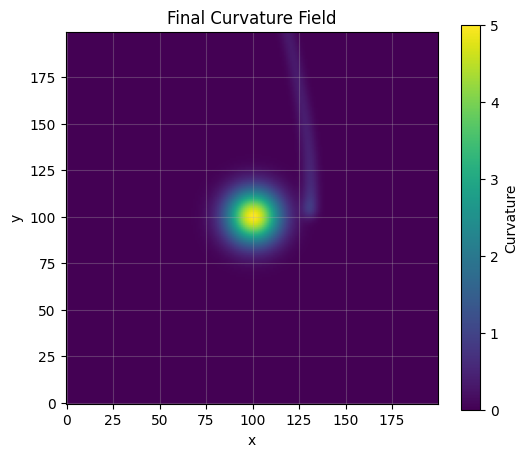

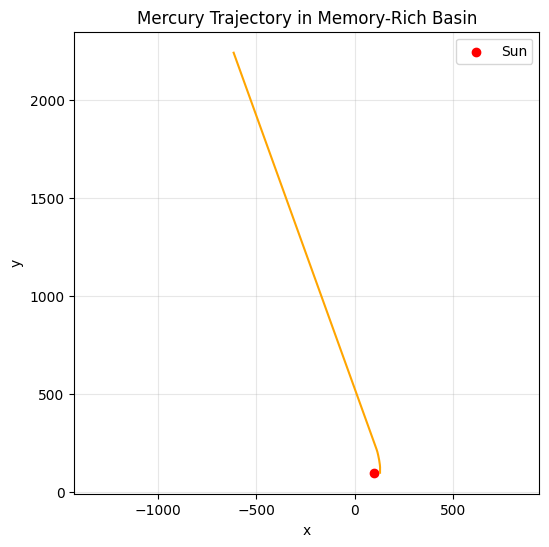

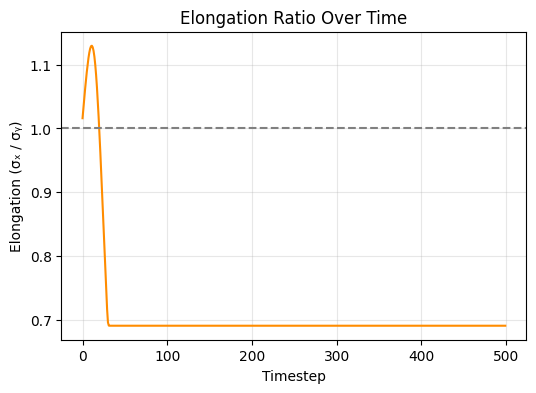

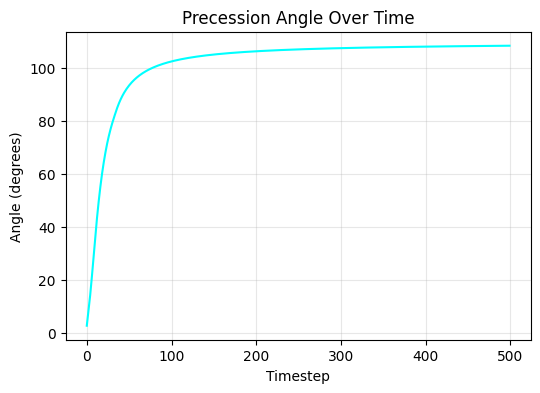

In [1]:
# TEG012 — Mass-Coupled Memory Dynamics
# Simulates orbital stability and memory-induced precession in pure HES

import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
grid_size = 200
timesteps = 500
A_sun = 5.0
sigma_sun = 10
A_mercury = 0.2
sigma_mercury = 3
dt = 1.0

# === Initialize Curvature Field ===
curvature = np.zeros((grid_size, grid_size))
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

# === Place Sun at Center ===
dx_sun = X - grid_size//2
dy_sun = Y - grid_size//2
sun_bowl = A_sun * np.exp(-(dx_sun**2 + dy_sun**2) / (2 * sigma_sun**2))
curvature += sun_bowl

# === Mercury Initial Conditions ===
pos = np.array([130.0, 100.0])
vel = np.array([0.0, 1.5])
trajectory = [pos.copy()]
elongation_history = []
precession_angles = []

# === Weighted Std Function ===
def weighted_std(values, weights):
    avg = np.average(values, weights=weights)
    var = np.average((values - avg)**2, weights=weights)
    return np.sqrt(var)

# === Simulation Loop ===
for t in range(timesteps):
    x, y = pos.astype(int)
    x = np.clip(x, 1, grid_size-2)
    y = np.clip(y, 1, grid_size-2)

    # Compute curvature gradient (force)
    grad_x = curvature[y, x+1] - curvature[y, x-1]
    grad_y = curvature[y+1, x] - curvature[y-1, x]
    force = -np.array([grad_x, grad_y])

    # Update velocity and position
    vel += force * dt
    pos += vel * dt
    trajectory.append(pos.copy())

    # Add memory bump at Mercury's position
    dx = X - pos[0]
    dy = Y - pos[1]
    bump = A_mercury * np.exp(-(dx**2 + dy**2) / (2 * sigma_mercury**2))
    curvature += bump

    # Elongation
    x_proj = np.sum(curvature, axis=0)
    y_proj = np.sum(curvature, axis=1)
    elong_x = weighted_std(np.arange(grid_size), x_proj)
    elong_y = weighted_std(np.arange(grid_size), y_proj)
    elongation_history.append(elong_x / (elong_y + 1e-8))

    # Precession angle
    dx_orbit = pos[0] - grid_size//2
    dy_orbit = pos[1] - grid_size//2
    angle = np.arctan2(dy_orbit, dx_orbit)
    precession_angles.append(np.degrees(angle))

# === Plot 1: Final Curvature Field ===
plt.figure(figsize=(6,5))
plt.imshow(curvature, cmap='viridis', origin='lower')
plt.colorbar(label='Curvature')
plt.title('Final Curvature Field')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

# === Plot 2: Mercury Trajectory ===
trajectory = np.array(trajectory)
plt.figure(figsize=(6,6))
plt.plot(trajectory[:,0], trajectory[:,1], color='orange')
plt.title('Mercury Trajectory in Memory-Rich Basin')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.scatter(grid_size//2, grid_size//2, color='red', label='Sun')
plt.legend()
plt.axis('equal')
plt.show()

# === Plot 3: Elongation Over Time ===
plt.figure(figsize=(6,4))
plt.plot(elongation_history, color='darkorange')
plt.title('Elongation Ratio Over Time')
plt.xlabel('Timestep'); plt.ylabel('Elongation (σₓ / σᵧ)')
plt.grid(alpha=0.3)
plt.axhline(1.0, color='gray', linestyle='--')
plt.show()

# === Plot 4: Precession Angle Over Time ===
plt.figure(figsize=(6,4))
plt.plot(precession_angles, color='cyan')
plt.title('Precession Angle Over Time')
plt.xlabel('Timestep'); plt.ylabel('Angle (degrees)')
plt.grid(alpha=0.3)
plt.show()
